In [96]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed


In [98]:
SEGMENTS = ["pre_meditation", "main_meditation", "recovery"]

VALID_EMOTIBIT_IDS = [
    "EmotiBit_1",
    "EmotiBit_2",
    "EmotiBit_3",
    "EmotiBit_4",
    "EmotiBit_6",
    "EmotiBit_7",
]

# suspected subcluster from your visual/correlation inspection
CANDIDATE_CLUSTER = ["EmotiBit_4", "EmotiBit_6", "EmotiBit_7"]

# winsorization for robustness
WINSOR_LOWER_Q = 0.05
WINSOR_UPPER_Q = 0.95

# sliding window settings (in seconds, since aligned HR is 1 Hz)
WINDOW_SEC = 30
STEP_SEC = 5
MIN_POINTS_PER_WINDOW = 20

In [99]:
def load_group_hr(segment):
    path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    if not path.exists():
        return None, path
    return pd.read_csv(path), path


def winsorize_series(s, lower_q=0.05, upper_q=0.95):
    s = pd.Series(s).copy()
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)


def winsorize_df(df, columns, lower_q=0.05, upper_q=0.95):
    out = df.copy()
    for c in columns:
        out[c] = winsorize_series(out[c], lower_q=lower_q, upper_q=upper_q)
    return out


def pairwise_corr_long(df, subject_cols):
    rows = []
    for a, b in itertools.combinations(subject_cols, 2):
        x = df[a]
        y = df[b]
        valid = x.notna() & y.notna()
        n = int(valid.sum())

        if n < 3:
            r = np.nan
        else:
            r = x[valid].corr(y[valid])

        rows.append({
            "subject_a": a,
            "subject_b": b,
            "n_points": n,
            "corr": r,
        })
    return pd.DataFrame(rows)


def mean_pairwise_corr(corr_long_df):
    vals = corr_long_df["corr"].dropna()
    if len(vals) == 0:
        return np.nan
    return float(vals.mean())


def median_pairwise_corr(corr_long_df):
    vals = corr_long_df["corr"].dropna()
    if len(vals) == 0:
        return np.nan
    return float(vals.median())


def build_corr_matrix(df, subject_cols):
    return df[subject_cols].corr()


def sliding_window_pairwise_mean(df, subject_cols, window_sec=30, step_sec=5, min_points=20):
    rows = []

    t = df["time_sec"].values.astype(float)
    if len(t) == 0:
        return pd.DataFrame(columns=["window_start", "window_end", "window_mid", "mean_pairwise_corr", "median_pairwise_corr"])

    start_t = t.min()
    end_t = t.max()

    ws = start_t
    while ws + window_sec <= end_t + 1e-9:
        we = ws + window_sec
        sub = df[(df["time_sec"] >= ws) & (df["time_sec"] < we)].copy()

        if len(sub) >= min_points:
            corr_long = pairwise_corr_long(sub, subject_cols)
            rows.append({
                "window_start": ws,
                "window_end": we,
                "window_mid": (ws + we) / 2.0,
                "mean_pairwise_corr": mean_pairwise_corr(corr_long),
                "median_pairwise_corr": median_pairwise_corr(corr_long),
            })

        ws += step_sec

    return pd.DataFrame(rows)


def cluster_pairwise_mean(corr_long_df, cluster_subjects):
    sub = corr_long_df[
        corr_long_df["subject_a"].isin(cluster_subjects) &
        corr_long_df["subject_b"].isin(cluster_subjects)
    ].copy()

    vals = sub["corr"].dropna()
    if len(vals) == 0:
        return np.nan
    return float(vals.mean())

In [100]:
segment_rows = []
pairwise_tables = {}

for segment in SEGMENTS:
    df, path = load_group_hr(segment)
    if df is None:
        print("Missing:", path)
        continue

    subject_cols = [c for c in VALID_EMOTIBIT_IDS if c in df.columns]

    # raw correlations
    corr_long_raw = pairwise_corr_long(df, subject_cols)
    corr_mat_raw = build_corr_matrix(df, subject_cols)

    # winsorized correlations
    df_win = winsorize_df(df, subject_cols, WINSOR_LOWER_Q, WINSOR_UPPER_Q)
    corr_long_win = pairwise_corr_long(df_win, subject_cols)
    corr_mat_win = build_corr_matrix(df_win, subject_cols)

    pairwise_tables[(segment, "raw")] = corr_long_raw
    pairwise_tables[(segment, "winsorized")] = corr_long_win

    segment_rows.append({
        "segment": segment,
        "n_timepoints": len(df),
        "mean_pairwise_corr_raw": mean_pairwise_corr(corr_long_raw),
        "median_pairwise_corr_raw": median_pairwise_corr(corr_long_raw),
        "mean_pairwise_corr_winsorized": mean_pairwise_corr(corr_long_win),
        "median_pairwise_corr_winsorized": median_pairwise_corr(corr_long_win),
        "cluster_467_mean_corr_raw": cluster_pairwise_mean(corr_long_raw, CANDIDATE_CLUSTER),
        "cluster_467_mean_corr_winsorized": cluster_pairwise_mean(corr_long_win, CANDIDATE_CLUSTER),
    })

    print(f"\n=== {segment} RAW correlation matrix ===")
    display(corr_mat_raw)

    print(f"\n=== {segment} WINSORIZED correlation matrix ===")
    display(corr_mat_win)

segment_sync_summary = pd.DataFrame(segment_rows)
display(segment_sync_summary)


=== pre_meditation RAW correlation matrix ===


,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
EmotiBit_1,1.000000,0.022431,-0.051222,0.027891,0.057152,0.025928
EmotiBit_2,0.022431,1.000000,0.013961,0.000515,0.027457,0.075200
EmotiBit_3,-0.051222,0.013961,1.000000,-0.024278,-0.055067,0.016992
EmotiBit_4,0.027891,0.000515,-0.024278,1.000000,0.106001,-0.073249
EmotiBit_6,0.057152,0.027457,-0.055067,0.106001,1.000000,-0.101125
EmotiBit_7,0.025928,0.075200,0.016992,-0.073249,-0.101125,1.000000



=== pre_meditation WINSORIZED correlation matrix ===


,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
EmotiBit_1,1.000000,0.016765,-0.050863,0.015031,0.098422,-0.010150
EmotiBit_2,0.016765,1.000000,0.002070,0.012224,0.024484,0.059860
EmotiBit_3,-0.050863,0.002070,1.000000,-0.058776,-0.074122,0.026304
EmotiBit_4,0.015031,0.012224,-0.058776,1.000000,0.122434,-0.140446
EmotiBit_6,0.098422,0.024484,-0.074122,0.122434,1.000000,-0.058397
EmotiBit_7,-0.010150,0.059860,0.026304,-0.140446,-0.058397,1.000000



=== main_meditation RAW correlation matrix ===


...


=== recovery RAW correlation matrix ===


,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
EmotiBit_1,1.000000,-0.156835,-0.092959,-0.130879,0.124295,0.031891
EmotiBit_2,-0.156835,1.000000,0.230094,0.000744,-0.078504,0.243274
EmotiBit_3,-0.092959,0.230094,1.000000,0.047645,0.067260,0.131842
EmotiBit_4,-0.130879,0.000744,0.047645,1.000000,-0.173628,-0.236656
EmotiBit_6,0.124295,-0.078504,0.067260,-0.173628,1.000000,-0.067369
EmotiBit_7,0.031891,0.243274,0.131842,-0.236656,-0.067369,1.000000



=== recovery WINSORIZED correlation matrix ===


,EmotiBit_1,EmotiBit_2,EmotiBit_3,EmotiBit_4,EmotiBit_6,EmotiBit_7
EmotiBit_1,1.000000,-0.111947,0.036922,-0.155288,0.103355,0.110228
EmotiBit_2,-0.111947,1.000000,0.296234,-0.004488,-0.104171,0.241000
EmotiBit_3,0.036922,0.296234,1.000000,-0.018026,0.081985,0.175107
EmotiBit_4,-0.155288,-0.004488,-0.018026,1.000000,-0.115390,-0.257527
EmotiBit_6,0.103355,-0.104171,0.081985,-0.115390,1.000000,-0.105700
EmotiBit_7,0.110228,0.241000,0.175107,-0.257527,-0.105700,1.000000


,segment,n_timepoints,mean_pairwise_corr_raw,median_pairwise_corr_raw,mean_pairwise_corr_winsorized,median_pairwise_corr_winsorized,cluster_467_mean_corr_raw,cluster_467_mean_corr_winsorized
0,pre_meditation,242,0.004572,0.016992,-0.001011,0.012224,-0.022791,-0.025470
1,main_meditation,752,0.045997,0.036377,0.046693,0.032718,0.194278,0.212368
2,recovery,93,-0.003986,0.000744,0.011486,-0.004488,-0.159217,-0.159539


In [101]:
out_path = TABLES_DIR / "group_synchrony_segment_summary.csv"
segment_sync_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_synchrony_segment_summary.csv


In [102]:
for (segment, kind), table in pairwise_tables.items():
    out_path = TABLES_DIR / f"group_pairwise_corr_{segment}_{kind}.csv"
    table.to_csv(out_path, index=False)
    print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_pairwise_corr_pre_meditation_raw.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_pairwise_corr_pre_meditation_winsorized.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_pairwise_corr_main_meditation_raw.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_pairwise_corr_main_meditation_winsorized.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_pairwise_corr_recovery_raw.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_pairwise_corr_recovery_winsorized.csv


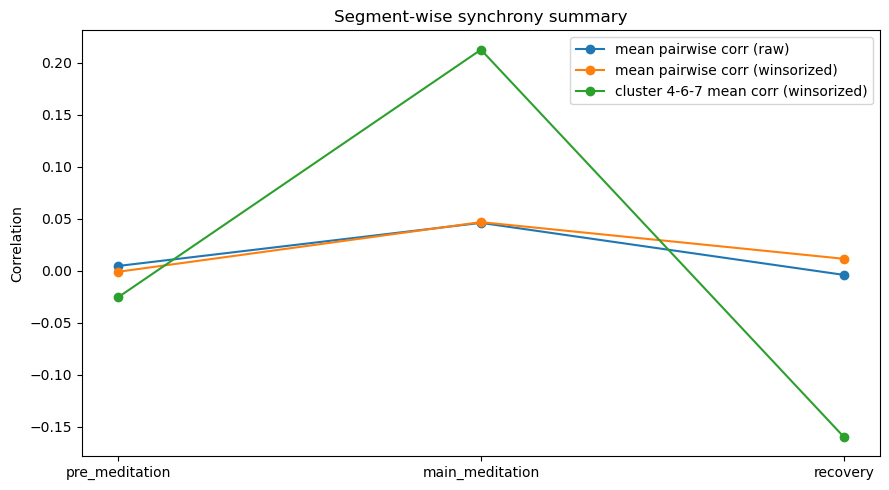

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/segment_wise_synchrony_summary.png


In [103]:
plot_df = segment_sync_summary.copy()

plt.figure(figsize=(9, 5))
x = np.arange(len(plot_df))

plt.plot(x, plot_df["mean_pairwise_corr_raw"], marker="o", label="mean pairwise corr (raw)")
plt.plot(x, plot_df["mean_pairwise_corr_winsorized"], marker="o", label="mean pairwise corr (winsorized)")
plt.plot(x, plot_df["cluster_467_mean_corr_winsorized"], marker="o", label="cluster 4-6-7 mean corr (winsorized)")

plt.xticks(x, plot_df["segment"])
plt.ylabel("Correlation")
plt.title("Segment-wise synchrony summary")
plt.legend()
plt.tight_layout()

out_path = FIGURES_DIR / "segment_wise_synchrony_summary.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [104]:
window_rows = []

for segment in SEGMENTS:
    df, path = load_group_hr(segment)
    if df is None:
        continue

    subject_cols = [c for c in VALID_EMOTIBIT_IDS if c in df.columns]

    # winsorize before windowed correlation
    df_win = winsorize_df(df, subject_cols, WINSOR_LOWER_Q, WINSOR_UPPER_Q)

    sw = sliding_window_pairwise_mean(
        df_win,
        subject_cols=subject_cols,
        window_sec=WINDOW_SEC,
        step_sec=STEP_SEC,
        min_points=MIN_POINTS_PER_WINDOW
    )
    sw["segment"] = segment

    # cluster 4-6-7 windowed
    cluster_rows = []
    t = df_win["time_sec"].values.astype(float)
    start_t = t.min()
    end_t = t.max()

    ws = start_t
    while ws + WINDOW_SEC <= end_t + 1e-9:
        we = ws + WINDOW_SEC
        sub = df_win[(df_win["time_sec"] >= ws) & (df_win["time_sec"] < we)].copy()

        if len(sub) >= MIN_POINTS_PER_WINDOW:
            corr_long = pairwise_corr_long(sub, CANDIDATE_CLUSTER)
            cluster_rows.append(cluster_pairwise_mean(corr_long, CANDIDATE_CLUSTER))
        ws += STEP_SEC

    if len(cluster_rows) == len(sw):
        sw["cluster_467_mean_corr"] = cluster_rows
    else:
        sw["cluster_467_mean_corr"] = np.nan

    window_rows.append(sw)

window_sync_df = pd.concat(window_rows, ignore_index=True)
display(window_sync_df.head(20))

,window_start,window_end,window_mid,mean_pairwise_corr,median_pairwise_corr,segment,cluster_467_mean_corr
0,1.429702,31.429702,16.429702,-0.015919,-0.031471,pre_meditation,0.049956
1,6.429702,36.429702,21.429702,0.009740,-0.011642,pre_meditation,0.002292
2,11.429702,41.429702,26.429702,-0.012013,0.011792,pre_meditation,0.092519
3,16.429702,46.429702,31.429702,-0.059145,0.006609,pre_meditation,-0.050804
4,21.429702,51.429702,36.429702,-0.056667,0.008301,pre_meditation,-0.054222
5,26.429702,56.429702,41.429702,-0.052211,-0.024331,pre_meditation,-0.050406
6,31.429702,61.429702,46.429702,-0.072421,-0.040975,pre_meditation,-0.053410
7,36.429702,66.429702,51.429702,-0.079243,-0.023148,pre_meditation,-0.090080
8,41.429702,71.429702,56.429702,-0.095259,-0.087963,pre_meditation,-0.285121
9,46.429702,76.429702,61.429702,-0.047641,-0.021593,pre_meditation,-0.180786


In [105]:
out_path = TABLES_DIR / "group_synchrony_sliding_windows.csv"
window_sync_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_synchrony_sliding_windows.csv


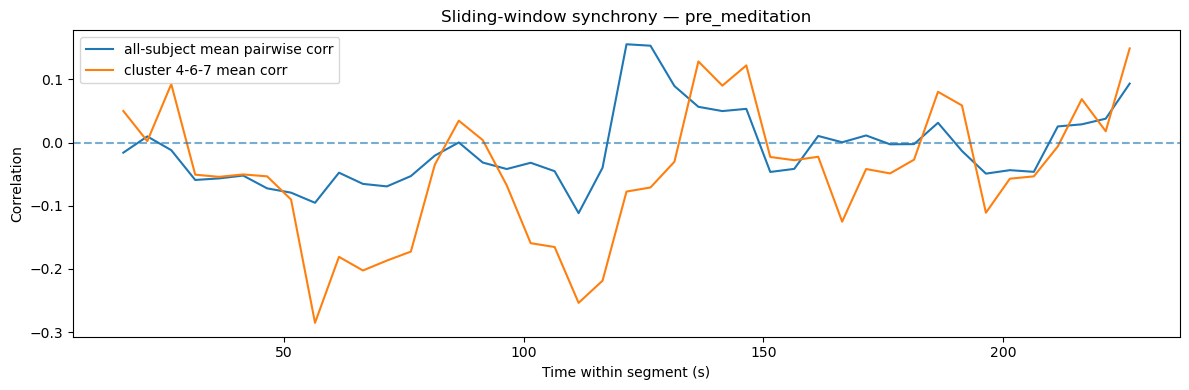

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/sliding_window_synchrony_pre_meditation.png


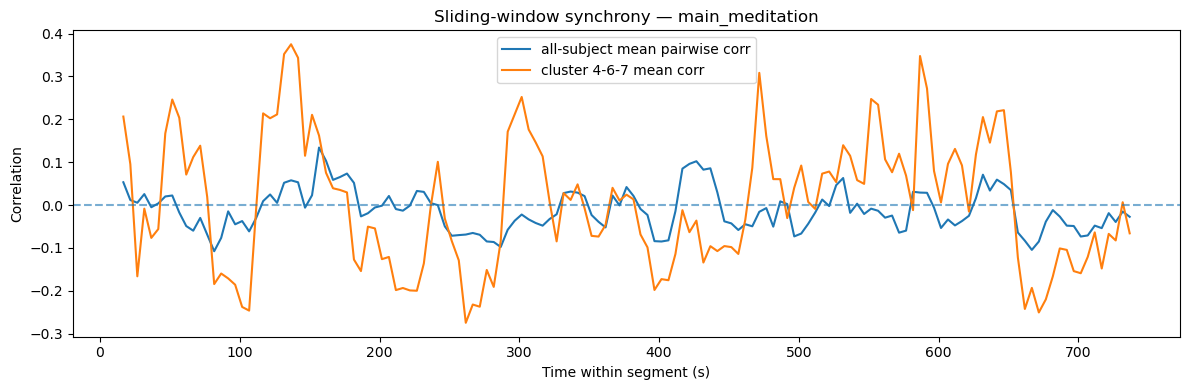

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/sliding_window_synchrony_main_meditation.png


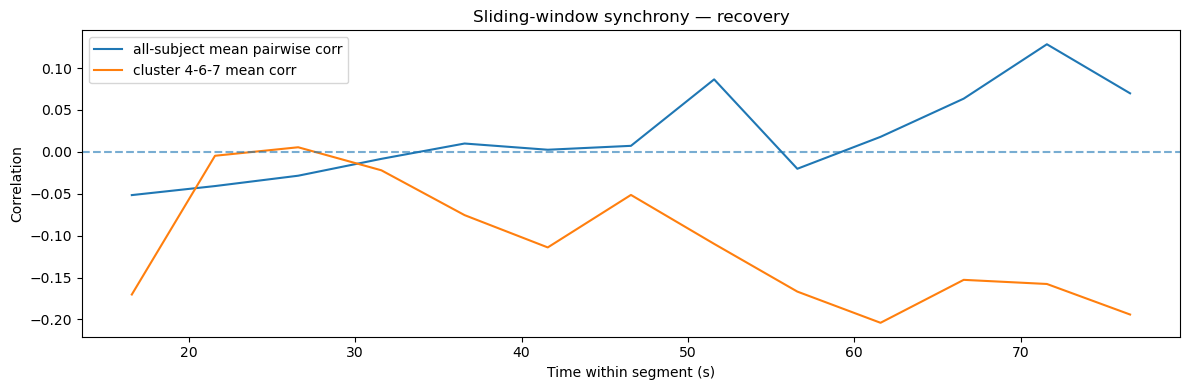

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/sliding_window_synchrony_recovery.png


In [106]:
for segment in SEGMENTS:
    sub = window_sync_df[window_sync_df["segment"] == segment].copy()
    if len(sub) == 0:
        continue

    plt.figure(figsize=(12, 4))
    plt.plot(sub["window_mid"], sub["mean_pairwise_corr"], label="all-subject mean pairwise corr")
    plt.plot(sub["window_mid"], sub["cluster_467_mean_corr"], label="cluster 4-6-7 mean corr")
    plt.axhline(0, linestyle="--", alpha=0.6)

    plt.title(f"Sliding-window synchrony — {segment}")
    plt.xlabel("Time within segment (s)")
    plt.ylabel("Correlation")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"sliding_window_synchrony_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [107]:
main_pairwise = pairwise_tables[("main_meditation", "winsorized")].copy()
main_pairwise = main_pairwise.sort_values("corr", ascending=False).reset_index(drop=True)
display(main_pairwise)

,subject_a,subject_b,n_points,corr
0,EmotiBit_4,EmotiBit_7,752,0.230585
1,EmotiBit_6,EmotiBit_7,752,0.213249
2,EmotiBit_4,EmotiBit_6,752,0.193268
3,EmotiBit_3,EmotiBit_4,752,0.070404
4,EmotiBit_2,EmotiBit_4,752,0.059553
5,EmotiBit_3,EmotiBit_6,752,0.036904
6,EmotiBit_1,EmotiBit_7,752,0.032953
7,EmotiBit_1,EmotiBit_6,752,0.032718
8,EmotiBit_2,EmotiBit_7,752,0.029976
9,EmotiBit_1,EmotiBit_4,752,0.027986


In [108]:
out_path = TABLES_DIR / "main_meditation_pairwise_ranked_winsorized.csv"
main_pairwise.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/main_meditation_pairwise_ranked_winsorized.csv


In [109]:
print("=== GROUP SYNCHRONY BASIC SUMMARY ===")
display(segment_sync_summary)

print("\nTop pairwise links in main meditation (winsorized):")
display(main_pairwise.head(10))

print("\nInterpretation guide:")
print("- If pre_meditation mean corr is near zero, that supports a null baseline.")
print("- If main_meditation mean corr rises, that supports greater synchrony during meditation.")
print("- If cluster 4-6-7 is stronger than whole-group mean, that supports a subgroup effect.")
print("- Sliding windows help show whether synchrony strengthens in the later part of meditation.")

=== GROUP SYNCHRONY BASIC SUMMARY ===


,segment,n_timepoints,mean_pairwise_corr_raw,median_pairwise_corr_raw,mean_pairwise_corr_winsorized,median_pairwise_corr_winsorized,cluster_467_mean_corr_raw,cluster_467_mean_corr_winsorized
0,pre_meditation,242,0.004572,0.016992,-0.001011,0.012224,-0.022791,-0.025470
1,main_meditation,752,0.045997,0.036377,0.046693,0.032718,0.194278,0.212368
2,recovery,93,-0.003986,0.000744,0.011486,-0.004488,-0.159217,-0.159539



Top pairwise links in main meditation (winsorized):


,subject_a,subject_b,n_points,corr
0,EmotiBit_4,EmotiBit_7,752,0.230585
1,EmotiBit_6,EmotiBit_7,752,0.213249
2,EmotiBit_4,EmotiBit_6,752,0.193268
3,EmotiBit_3,EmotiBit_4,752,0.070404
4,EmotiBit_2,EmotiBit_4,752,0.059553
5,EmotiBit_3,EmotiBit_6,752,0.036904
6,EmotiBit_1,EmotiBit_7,752,0.032953
7,EmotiBit_1,EmotiBit_6,752,0.032718
8,EmotiBit_2,EmotiBit_7,752,0.029976
9,EmotiBit_1,EmotiBit_4,752,0.027986



Interpretation guide:
- If pre_meditation mean corr is near zero, that supports a null baseline.
- If main_meditation mean corr rises, that supports greater synchrony during meditation.
- If cluster 4-6-7 is stronger than whole-group mean, that supports a subgroup effect.
- Sliding windows help show whether synchrony strengthens in the later part of meditation.


In [110]:
print("=== NEXT STEP ===")
print("If these basic synchrony patterns look promising, the next notebook should add:")
print("1. surrogate / null testing")
print("2. significance testing for real vs shuffled group")
print("3. maybe lagged/windowed variants")

=== NEXT STEP ===
If these basic synchrony patterns look promising, the next notebook should add:
1. surrogate / null testing
2. significance testing for real vs shuffled group
3. maybe lagged/windowed variants
